# USD/ZAR one-month-ahead forecasts: final Huber model

**Task.** Produce a USD/ZAR forecast every Friday, one month ahead, and compare its
out-of-sample RMSE with an AR(1) benchmark from 1 January 2021 through
31 December 2025.

**Headline design.** This notebook uses the Huber model selected in
`final_models.ipynb`: a robust linear regression with the same three predictors,
standardisation of both predictors and target, and the same hyperparameters
(`epsilon=1.35`, `alpha=0.01`). The forecast target is the change in USD/ZAR:

\[
\Delta s_{t,t+1m}=s_{t+1m}-s_t .
\]

The target rate is the observation attached to the Friday nearest to one calendar
month after the forecast Friday (with the latest available observation on or before
a holiday Friday). The level forecast is \(s_t+\widehat{\Delta s}_{t,t+1m}\).

The evaluation is genuinely out of sample: for each Friday in 2021–2025, both
models are re-estimated using only information—and training outcomes—that would
have been observable by that forecast origin. No 2021–2025 outcome is used before
it becomes known.

## 1. Imports and reproducibility

All inputs are local project files, so the notebook is reproducible without API
credentials. The source USD/ZAR file was downloaded from EconData's South African
Reserve Bank **Market Rates** dataset, series **EXCX135**. USD/ZAR is quoted as rand
per US dollar, so an increase is a depreciation of the rand.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Work whether launched from the repository root or from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "train.parquet").exists(), "Could not locate project data."

FORECAST_START = pd.Timestamp("2021-01-01")
FORECAST_END = pd.Timestamp("2025-12-31")
FEATURES = ["sa_repo_rate", "usd_zar_1m_return", "sa_cpi_log_change_21d"]

## 2. Load and verify the data

The modelling panel supplies the three predictors. The clean SARB series supplies
the exchange-rate outcomes, including January 2026 rates needed to score forecasts
made in December 2025. We explicitly verify that the panel's USD/ZAR values agree
with the SARB series on their common dates.

In [2]:
panel = (
    pd.concat(
        [
            pd.read_parquet(ROOT / "data" / "train.parquet"),
            pd.read_parquet(ROOT / "data" / "test.parquet"),
        ],
        ignore_index=True,
    )
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)
panel["date"] = pd.to_datetime(panel["date"])

sarb = (
    pd.read_csv(ROOT / "data" / "usdzar_clean.csv", parse_dates=["date"])
    .rename(columns={"usdzar": "sarb_usd_zar"})
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)
# pandas may parse CSV timestamps at microsecond precision while Parquet uses
# nanoseconds; merge_asof requires identical datetime resolution.
sarb["date"] = sarb["date"].astype("datetime64[ns]")

check = panel[["date", "usd_zar"]].merge(sarb, on="date", how="inner").dropna()
max_source_difference = (check["usd_zar"] - check["sarb_usd_zar"]).abs().max()
assert max_source_difference < 1e-10

source_summary = pd.DataFrame(
    {
        "Series": ["Modelling panel", "SARB USD/ZAR (EXCX135)"],
        "Start": [panel["date"].min(), sarb["date"].min()],
        "End": [panel["date"].max(), sarb["date"].max()],
        "Observations": [len(panel), len(sarb)],
        "Missing USD/ZAR": [panel["usd_zar"].isna().sum(), sarb["sarb_usd_zar"].isna().sum()],
    }
)
display(source_summary)
print(f"Maximum panel-versus-SARB USD/ZAR difference: {max_source_difference:.10f}")

,Series,Start,End,Observations,Missing USD/ZAR
0,Modelling panel,2008-10-10,2025-12-31,4494,0
1,SARB USD/ZAR (EXCX135),1970-01-02,2026-07-17,14173,0


Maximum panel-versus-SARB USD/ZAR difference: 0.0000000000


## 3. Daily training sample and Friday evaluation targets

The selected Huber model uses:

- `sa_repo_rate`: the South African policy rate (%);
- `usd_zar_1m_return`: the trailing 21-observation USD/ZAR return;
- `sa_cpi_log_change_21d`: \(\log(CPI_t)-\log(CPI_{t-21})\).

The first two were already prepared in the modelling panel. CPI log change is
recreated exactly as in `final_models.ipynb`. It is backward-looking: its value at
an origin uses no future row.

**Training frequency and evaluation frequency are deliberately different.** The
Huber model is trained on every available daily panel observation, with its target
set to the nearest available SARB rate one calendar month later. This maximises
the estimation information. Forecasts are issued and scored only on Fridays from
2021–2025, as required by the task.

For holiday Fridays, the evaluation origin rate and features are the latest
observation available on or before that Friday. A forecast's target Friday is the
grid Friday nearest to `origin Friday + 1 calendar month`; the target exchange
rate is the latest SARB observation on or before that target Friday.

In [3]:
panel["sa_cpi_log_change_21d"] = np.log(panel["sa_cpi"]).diff(21)

# ---------------------------------------------------------------------------
# DAILY TRAINING ROWS
# Each panel date is a possible estimation origin. Its target is the nearest
# available SARB observation to one calendar month later.
# ---------------------------------------------------------------------------
daily_supervised = panel[["date", "usd_zar", *FEATURES]].copy().rename(
    columns={"date": "origin_actual_date", "usd_zar": "origin_usd_zar"}
)
daily_supervised["target_date_approx"] = (
    daily_supervised["origin_actual_date"] + pd.DateOffset(months=1)
)
daily_targets = sarb.rename(
    columns={"date": "target_actual_date", "sarb_usd_zar": "target_usd_zar"}
)
daily_supervised = pd.merge_asof(
    daily_supervised.sort_values("target_date_approx"),
    daily_targets.sort_values("target_actual_date"),
    left_on="target_date_approx",
    right_on="target_actual_date",
    direction="nearest",
).sort_values("origin_actual_date").reset_index(drop=True)
daily_supervised = daily_supervised[
    daily_supervised["target_actual_date"].gt(daily_supervised["origin_actual_date"])
].copy()
daily_supervised["target_movement"] = (
    daily_supervised["target_usd_zar"] - daily_supervised["origin_usd_zar"]
)

# ---------------------------------------------------------------------------
# FRIDAY EVALUATION ROWS
# Features and rates are merged backward for holiday Fridays, never forward.
# ---------------------------------------------------------------------------
first_friday = panel["date"].min() + pd.offsets.Week(weekday=4)
last_target_friday = FORECAST_END + pd.DateOffset(months=1) + pd.offsets.Week(weekday=4)
friday_grid = pd.DataFrame(
    {"origin_friday": pd.date_range(first_friday, last_target_friday, freq="W-FRI")}
)

feature_columns = ["date", "usd_zar", *FEATURES]
origins = pd.merge_asof(
    friday_grid,
    panel[feature_columns].dropna(subset=["usd_zar"]).sort_values("date"),
    left_on="origin_friday",
    right_on="date",
    direction="backward",
).rename(columns={"date": "origin_actual_date", "usd_zar": "origin_usd_zar"})

friday_rates = pd.merge_asof(
    friday_grid,
    sarb,
    left_on="origin_friday",
    right_on="date",
    direction="backward",
).rename(columns={"date": "rate_actual_date", "sarb_usd_zar": "friday_usd_zar"})

origins = origins.drop(columns="origin_usd_zar").merge(
    friday_rates[["origin_friday", "rate_actual_date", "friday_usd_zar"]],
    on="origin_friday",
    how="left",
).rename(
    columns={"rate_actual_date": "origin_rate_date", "friday_usd_zar": "origin_usd_zar"}
)

targets = origins[["origin_friday", "origin_rate_date", "origin_usd_zar"]].rename(
    columns={
        "origin_friday": "target_friday",
        "origin_rate_date": "target_actual_date",
        "origin_usd_zar": "target_usd_zar",
    }
)
origins["target_date_approx"] = origins["origin_friday"] + pd.DateOffset(months=1)
supervised = pd.merge_asof(
    origins.sort_values("target_date_approx"),
    targets.sort_values("target_friday"),
    left_on="target_date_approx",
    right_on="target_friday",
    direction="nearest",
).sort_values("origin_friday").reset_index(drop=True)

supervised = supervised[
    supervised["target_actual_date"].gt(supervised["origin_rate_date"])
].copy()
supervised["target_movement"] = (
    supervised["target_usd_zar"] - supervised["origin_usd_zar"]
)
supervised["calendar_horizon"] = (
    supervised["target_actual_date"] - supervised["origin_rate_date"]
).dt.days

assert (supervised["origin_actual_date"] <= supervised["origin_friday"]).all()
assert (supervised["origin_rate_date"] <= supervised["origin_friday"]).all()
assert (supervised["target_actual_date"] > supervised["origin_rate_date"]).all()

print(f"Daily candidate training rows: {len(daily_supervised):,}")
print(
    "Friday evaluation rows: "
    f"{supervised['origin_friday'].between(FORECAST_START, FORECAST_END).sum():,}"
)
display(
    supervised.loc[
        supervised["origin_friday"].between(FORECAST_START, FORECAST_END),
        [
            "origin_friday", "origin_actual_date", "origin_usd_zar",
            "target_friday", "target_actual_date", "target_usd_zar",
            "calendar_horizon",
        ],
    ].head()
)

Daily candidate training rows: 4,494
Friday evaluation rows: 261


,origin_friday,origin_actual_date,origin_usd_zar,target_friday,target_actual_date,target_usd_zar,calendar_horizon
637,2021-01-01,2021-01-01,14.6246,2021-01-29,2021-01-29,15.1903,29
638,2021-01-08,2021-01-08,15.3661,2021-02-05,2021-02-05,14.9266,28
639,2021-01-15,2021-01-15,15.1810,2021-02-12,2021-02-12,14.6610,28
640,2021-01-22,2021-01-22,15.0771,2021-02-19,2021-02-19,14.5616,28
641,2021-01-29,2021-01-29,15.1903,2021-02-26,2021-02-26,14.8367,28


## 4. Model definitions

### Huber regression

Huber regression is linear for ordinary residuals but changes from squared-error
loss to linear loss for unusually large standardised residuals. Consequently,
isolated exchange-rate shocks have less influence than under ordinary least
squares. `StandardScaler` puts predictors on comparable scales; the transformed
target wrapper also standardises the movement being predicted. `alpha=0.01`
adds L2 regularisation, while `epsilon=1.35` sets the robust-loss transition.

### AR(1) benchmark

The benchmark estimates
\(\log(s_t)=c+\phi\log(s_{t-1})+u_t\) on SARB observations available at each
origin, then iterates it to the target. Both forecasts are converted to USD/ZAR
levels and scored against exactly the same target observations.

In [4]:
def make_huber_model():
    # Exact chosen specification from final_models.ipynb.
    return TransformedTargetRegressor(
        regressor=make_pipeline(
            StandardScaler(),
            HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=2_000),
        ),
        transformer=StandardScaler(),
    )


def fit_ar1(log_rates):
    model = LinearRegression()
    model.fit(log_rates[:-1].reshape(-1, 1), log_rates[1:])
    return float(model.intercept_), float(model.coef_[0])


def iterated_ar1_level(spot, intercept, phi, steps):
    log_spot = np.log(spot)
    if np.isclose(phi, 1.0):
        log_forecast = log_spot + intercept * steps
    else:
        log_forecast = (
            phi**steps * log_spot
            + intercept * (1 - phi**steps) / (1 - phi)
        )
    return float(np.exp(log_forecast))

## 5. Walk-forward out-of-sample forecasts

At forecast origin \(t\), a daily Huber training row is eligible only when its own
target observation date is on or before \(t\). This rule prevents target leakage:
recent daily rows whose one-month outcomes were not yet known are excluded.

The model uses an expanding **daily** estimation window and is refitted for each
Friday forecast. Therefore later forecasts may learn from earlier 2021–2025 daily
outcomes after those outcomes have actually occurred, which is the information set
a real forecaster would possess. Evaluation remains exclusively on the 261 Friday
origins. The AR(1) is also re-estimated at every Friday origin using SARB rates
dated no later than that origin.

In [5]:
evaluation_rows = supervised[
    supervised["origin_friday"].between(FORECAST_START, FORECAST_END)
    & supervised[FEATURES].notna().all(axis=1)
    & supervised["target_usd_zar"].notna()
].copy()

results = []
for row in evaluation_rows.itertuples(index=False):
    # Use ALL daily examples that are fully observed and whose one-month outcome
    # was already known at this Friday origin.
    known = (
        daily_supervised["target_actual_date"].le(row.origin_rate_date)
        & daily_supervised[FEATURES].notna().all(axis=1)
        & daily_supervised["target_movement"].notna()
    )
    training = daily_supervised.loc[known].copy()

    huber = make_huber_model()
    huber.fit(training[FEATURES], training["target_movement"])
    huber_movement = float(
        huber.predict(pd.DataFrame([{f: getattr(row, f) for f in FEATURES}]))[0]
    )
    huber_level = row.origin_usd_zar + huber_movement

    # Daily SARB observations available by the origin only.
    ar_history = sarb.loc[
        sarb["date"].le(row.origin_rate_date), ["date", "sarb_usd_zar"]
    ].dropna()
    c, phi = fit_ar1(np.log(ar_history["sarb_usd_zar"].to_numpy()))

    # Number of SARB observation transitions between origin and target.
    ar_steps = int(
        sarb["date"].gt(row.origin_rate_date)
        .where(sarb["date"].le(row.target_actual_date), False)
        .sum()
    )
    ar1_level = iterated_ar1_level(row.origin_usd_zar, c, phi, ar_steps)

    results.append(
        {
            "origin_friday": row.origin_friday,
            "origin_actual_date": row.origin_rate_date,
            "target_friday": row.target_friday,
            "target_actual_date": row.target_actual_date,
            "origin_usd_zar": row.origin_usd_zar,
            "actual_usd_zar": row.target_usd_zar,
            "huber_forecast": huber_level,
            "ar1_forecast": ar1_level,
            "huber_error": huber_level - row.target_usd_zar,
            "ar1_error": ar1_level - row.target_usd_zar,
            "training_observations": len(training),
            "training_start": training["origin_actual_date"].min(),
            "training_latest_known_target": training["target_actual_date"].max(),
            "ar1_phi": phi,
            "ar1_steps": ar_steps,
        }
    )

results = pd.DataFrame(results)
assert len(results) == len(evaluation_rows)
assert results["origin_friday"].between(FORECAST_START, FORECAST_END).all()
assert (
    results["training_latest_known_target"] <= results["origin_actual_date"]
).all()

display(results.head())
print(f"Forecasts produced and evaluated (Fridays only): {len(results)}")

,origin_friday,origin_actual_date,target_friday,target_actual_date,origin_usd_zar,actual_usd_zar,huber_forecast,ar1_forecast,huber_error,ar1_error,training_observations,training_start,training_latest_known_target,ar1_phi,ar1_steps
0,2021-01-01,2020-12-31,2021-01-29,2021-01-29,14.6246,15.1903,14.7782,14.6724,-0.4121,-0.5179,3148,2008-11-10,2020-12-31,1.0000,20
1,2021-01-08,2021-01-08,2021-02-05,2021-02-05,15.3661,14.9266,15.4844,15.4193,0.5578,0.4927,3153,2008-11-10,2021-01-08,1.0000,20
2,2021-01-15,2021-01-15,2021-02-12,2021-02-12,15.1810,14.6610,15.3007,15.2327,0.6397,0.5717,3158,2008-11-10,2021-01-15,1.0000,20
3,2021-01-22,2021-01-22,2021-02-19,2021-02-19,15.0771,14.5616,15.1981,15.1280,0.6365,0.5664,3163,2008-11-10,2021-01-22,1.0000,20
4,2021-01-29,2021-01-29,2021-02-26,2021-02-26,15.1903,14.8367,15.3132,15.2419,0.4765,0.4052,3168,2008-11-10,2021-01-29,1.0000,20


Forecasts produced and evaluated (Fridays only): 261


## 6. Sample and summary statistics

`Forecast origins` counts only the Friday forecasts being judged. The Huber
training counts are much larger because every eligible daily observation is used.
The first forecast can use only daily outcomes known at its origin; the expanding
window then grows over the evaluation.

In [6]:
sample_summary = pd.DataFrame(
    {
        "Measure": [
            "Friday forecast origins evaluated",
            "Forecast-origin start",
            "Forecast-origin end",
            "First target date",
            "Last target date",
            "Initial daily Huber training observations",
            "Final daily Huber training observations",
            "Predictors",
            "Median evaluation horizon (days)",
        ],
        "Value": [
            len(results),
            results["origin_friday"].min().date(),
            results["origin_friday"].max().date(),
            results["target_actual_date"].min().date(),
            results["target_actual_date"].max().date(),
            int(results["training_observations"].iloc[0]),
            int(results["training_observations"].iloc[-1]),
            len(FEATURES),
            int(evaluation_rows["calendar_horizon"].median()),
        ],
    }
)
display(sample_summary)

estimation_at_first_origin = daily_supervised[
    daily_supervised["target_actual_date"].le(results["origin_actual_date"].iloc[0])
    & daily_supervised[FEATURES].notna().all(axis=1)
]
feature_stats = estimation_at_first_origin[
    ["origin_usd_zar", *FEATURES, "target_movement"]
].describe().T.rename_axis("Series")
display(feature_stats)

,Measure,Value
0,Friday forecast origins evaluated,261
1,Forecast-origin start,2021-01-01
2,Forecast-origin end,2025-12-26
3,First target date,2021-01-29
4,Last target date,2026-01-23
5,Initial daily Huber training observations,3148
6,Final daily Huber training observations,4448
7,Predictors,3
8,Median evaluation horizon (days),28


,count,mean,std,min,25%,50%,75%,max
Series,,,,,,,,
origin_usd_zar,"3,148.0000",11.3499,3.1182,6.5962,8.2392,11.2147,14.0066,19.0768
sa_repo_rate,"3,148.0000",6.2009,1.3221,3.5000,5.5000,6.2500,6.7500,12.0000
usd_zar_1m_return,"3,148.0000",0.0038,0.0430,-0.1490,-0.0253,0.0008,0.0294,0.2239
sa_cpi_log_change_21d,"3,148.0000",0.0039,0.0041,-0.0075,0.0013,0.0034,0.0062,0.0251
target_movement,"3,148.0000",0.0321,0.5448,-1.8343,-0.2679,0.0002,0.3178,3.7432


## 7. Series used by the model

The vertical line marks the start of formal out-of-sample evaluation. The plots
show the exchange-rate level needed to translate movement forecasts into levels
and all three Huber predictors.

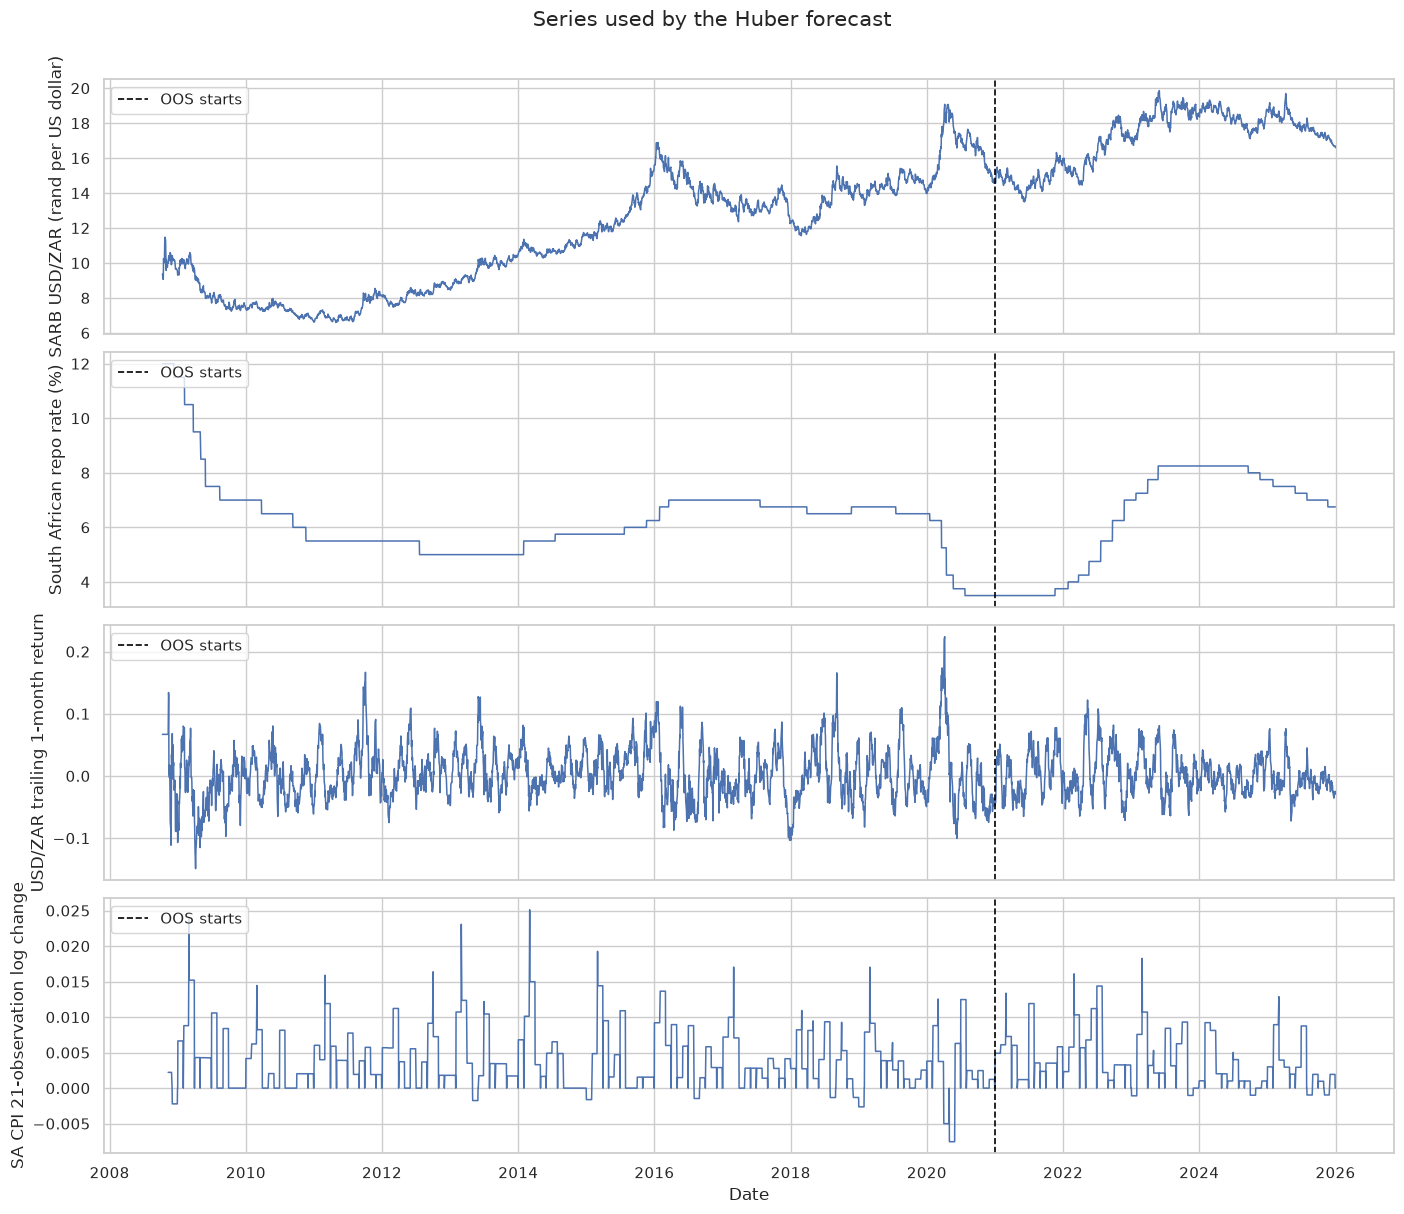

In [7]:
plot_data = panel[panel["date"].ge(pd.Timestamp("2008-10-01"))].copy()
series_to_plot = [
    ("usd_zar", "SARB USD/ZAR (rand per US dollar)"),
    ("sa_repo_rate", "South African repo rate (%)"),
    ("usd_zar_1m_return", "USD/ZAR trailing 1-month return"),
    ("sa_cpi_log_change_21d", "SA CPI 21-observation log change"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (column, label) in zip(axes, series_to_plot):
    ax.plot(plot_data["date"], plot_data[column], lw=1.1)
    ax.axvline(FORECAST_START, color="black", ls="--", lw=1.2, label="OOS starts")
    ax.set_ylabel(label)
    ax.legend(loc="upper left")
fig.suptitle("Series used by the Huber forecast", fontsize=15, y=1.01)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 8. Forecast performance and RMSE comparison

RMSE is \(\sqrt{N^{-1}\sum(\widehat{s}_{t+1m}-s_{t+1m})^2}\), in rand per US
dollar. Lower is better. Both models use the same forecast origins and outcomes.
Numbers are printed directly on the required comparison chart.

,Model,RMSE
0,Huber,0.5586
1,AR(1),0.5624


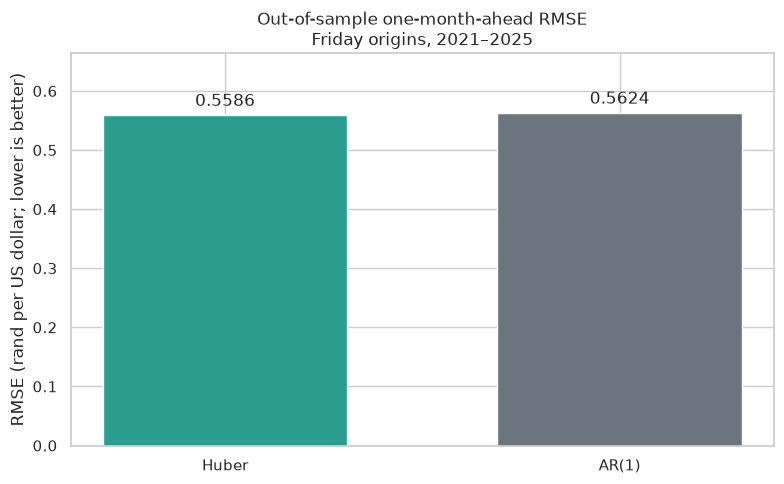

In [8]:
rmse_table = pd.DataFrame(
    {
        "Model": ["Huber", "AR(1)"],
        "RMSE": [
            root_mean_squared_error(results["actual_usd_zar"], results["huber_forecast"]),
            root_mean_squared_error(results["actual_usd_zar"], results["ar1_forecast"]),
        ],
    }
).sort_values("RMSE").reset_index(drop=True)
display(rmse_table)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2a9d8f" if m == "Huber" else "#6c757d" for m in rmse_table["Model"]]
bars = ax.bar(rmse_table["Model"], rmse_table["RMSE"], color=colors, width=0.62)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in rmse_table["RMSE"]], padding=4, fontsize=12)
ax.set_title("Out-of-sample one-month-ahead RMSE\nFriday origins, 2021–2025")
ax.set_ylabel("RMSE (rand per US dollar; lower is better)")
ax.set_ylim(0, rmse_table["RMSE"].max() * 1.18)
plt.tight_layout()
plt.show()

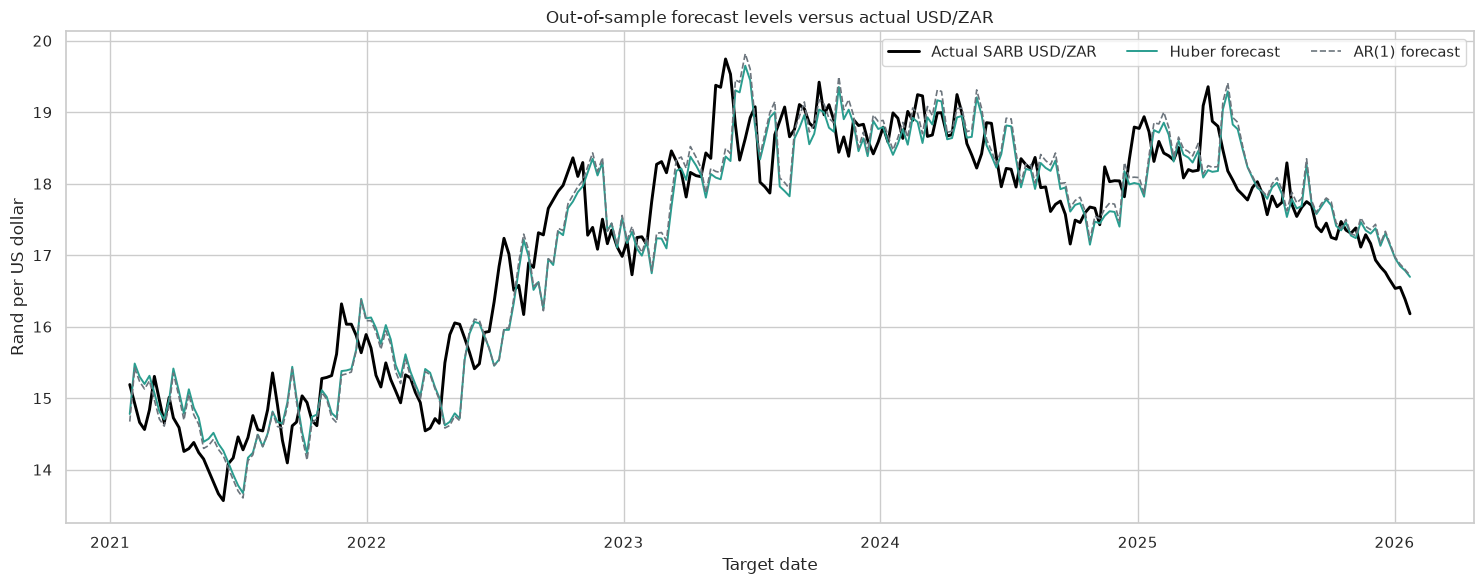

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(results["target_actual_date"], results["actual_usd_zar"],
        color="black", lw=2.1, label="Actual SARB USD/ZAR")
ax.plot(results["target_actual_date"], results["huber_forecast"],
        color="#2a9d8f", lw=1.4, label="Huber forecast")
ax.plot(results["target_actual_date"], results["ar1_forecast"],
        color="#6c757d", lw=1.2, ls="--", label="AR(1) forecast")
ax.set_title("Out-of-sample forecast levels versus actual USD/ZAR")
ax.set_xlabel("Target date")
ax.set_ylabel("Rand per US dollar")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## 9. Interpreting the final Huber model

For interpretation, the model is fitted once more using every **daily** row whose
target was known at the final 2025 forecast origin. Because both inputs and target
were standardised, the displayed coefficients are comparable: their signs show
the direction of the predicted one-month USD/ZAR movement, holding other
predictors fixed. The walk-forward forecasts above still come from the
historically correct model at each Friday origin, not this final explanatory fit.

In [10]:
final_known = (
    daily_supervised["target_actual_date"].le(results["origin_actual_date"].iloc[-1])
    & daily_supervised[FEATURES].notna().all(axis=1)
    & daily_supervised["target_movement"].notna()
)
final_huber = make_huber_model()
final_huber.fit(
    daily_supervised.loc[final_known, FEATURES],
    daily_supervised.loc[final_known, "target_movement"],
)
fitted_regressor = final_huber.regressor_.named_steps["huberregressor"]
coefficient_table = pd.DataFrame(
    {
        "Predictor": FEATURES,
        "Standardised coefficient": fitted_regressor.coef_,
    }
).sort_values("Standardised coefficient", key=abs, ascending=False)
display(coefficient_table)

,Predictor,Standardised coefficient
0,sa_repo_rate,-0.1073
1,usd_zar_1m_return,-0.0666
2,sa_cpi_log_change_21d,-0.0241


## 10. Audit trail and conclusion

The first rows below make the out-of-sample claim auditable. For every Friday
forecast, `latest target used for training` is no later than the corresponding
`information cutoff`. The training counts refer to daily observations. Thus the
model uses the full daily estimation sample without ever training on an outcome
that was unknown when a forecast was issued.

In [11]:
audit = results[
    [
        "origin_friday",
        "origin_actual_date",
        "training_latest_known_target",
        "training_observations",
        "target_actual_date",
    ]
].rename(
    columns={
        "origin_friday": "forecast Friday",
        "origin_actual_date": "information cutoff",
        "training_latest_known_target": "latest target used for training",
        "training_observations": "training observations",
        "target_actual_date": "forecast target observed",
    }
)
display(audit.head(10))

huber_rmse = rmse_table.loc[rmse_table["Model"].eq("Huber"), "RMSE"].iloc[0]
ar1_rmse = rmse_table.loc[rmse_table["Model"].eq("AR(1)"), "RMSE"].iloc[0]
winner = "Huber" if huber_rmse < ar1_rmse else "AR(1)"
relative = abs(huber_rmse / ar1_rmse - 1) * 100
comparison_word = "lower" if huber_rmse < ar1_rmse else "higher"

print(
    f"Conclusion: {winner} has the lower out-of-sample RMSE. "
    f"Huber RMSE is {huber_rmse:.4f}, versus {ar1_rmse:.4f} for AR(1); "
    f"Huber's RMSE is {relative:.2f}% {comparison_word}."
)

,forecast Friday,information cutoff,latest target used for training,training observations,forecast target observed
0,2021-01-01,2020-12-31,2020-12-31,3148,2021-01-29
1,2021-01-08,2021-01-08,2021-01-08,3153,2021-02-05
2,2021-01-15,2021-01-15,2021-01-15,3158,2021-02-12
3,2021-01-22,2021-01-22,2021-01-22,3163,2021-02-19
4,2021-01-29,2021-01-29,2021-01-29,3168,2021-02-26
5,2021-02-05,2021-02-05,2021-02-05,3173,2021-03-05
6,2021-02-12,2021-02-12,2021-02-12,3178,2021-03-12
7,2021-02-19,2021-02-19,2021-02-19,3183,2021-03-19
8,2021-02-26,2021-02-26,2021-02-26,3188,2021-03-26
9,2021-03-05,2021-03-05,2021-03-05,3195,2021-04-01


Conclusion: Huber has the lower out-of-sample RMSE. Huber RMSE is 0.5586, versus 0.5624 for AR(1); Huber's RMSE is 0.68% lower.


### Limitations

- The predictors in the prepared panel are treated as available on their recorded
  dates. A production vintage-data exercise would additionally preserve the
  original release vintage of low-frequency macroeconomic data.
- Friday scoring creates overlapping one-month horizons. RMSE remains a valid
  descriptive accuracy measure, but ordinary independent-error inference would
  not be appropriate without a correction for overlap.
- The Huber model is intentionally parsimonious and linear. Its main benefit is
  robustness to large exchange-rate shocks, not the modelling of nonlinear
  regimes.

The `results` DataFrame contains every forecast, actual, error, origin, target, and
training cutoff required to reproduce or audit the reported RMSEs.